# Homework

## Problem 1

Let $f(x) = 2\sin x - \cos{2x}$. Write a function `beauty_derivative_plot` that takes a point $x$ and plots the function $f(x)$ and its derivative $f'(x)$ in the range $x \in [-2\pi, 2\pi]$. The function should also plot the tangent line to the function at the point $x$.

Example of output for $x = -3, -2, 1.7$:

```python
beauty_derivative_plot(-3)
```
<img src="https://i.ibb.co/zTdYLC0J/tangent-line-3-0.png" width="600"/>

```python
beauty_derivative_plot(-2)
```
<img src="https://i.ibb.co/hFXNZ7wS/tangent-line-2-0.png" width="600"/>

```python
beauty_derivative_plot(1.7)
```
<img src="https://i.ibb.co/217yHstn/tangent-line-1-7.png" width="600"/>

Введите точку x (от -2π до 2π): 3


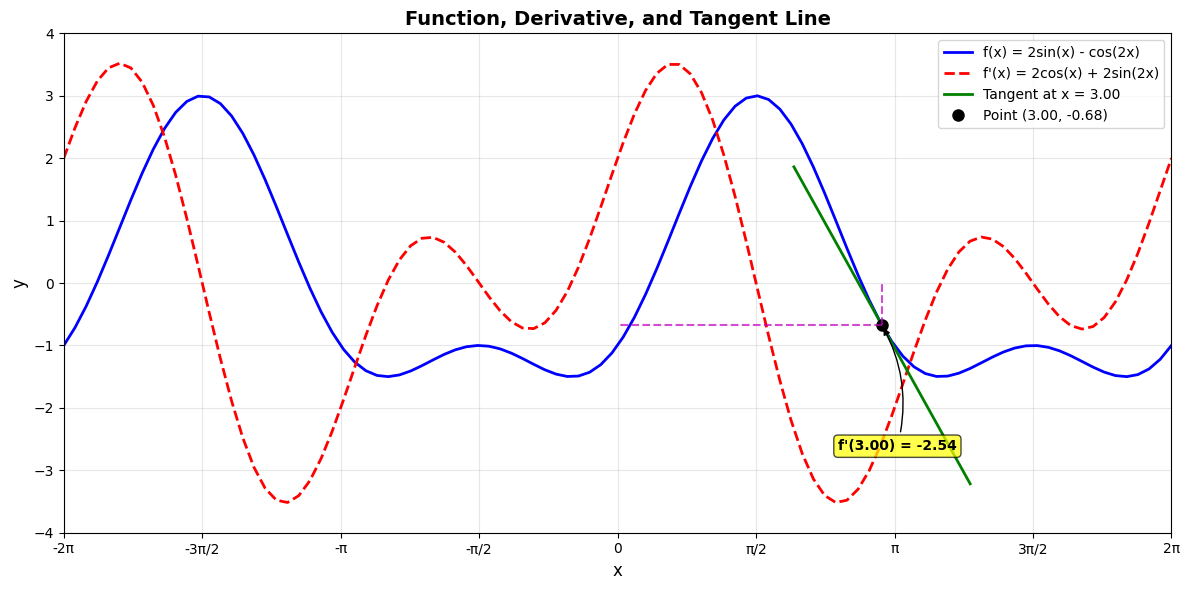

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def beauty_derivative_plot(point: float) -> None:

    x_values = np.linspace(-2 * np.pi, 2 * np.pi, 100)

    # Определяем исходную функцию
    f = lambda x: 2 * np.sin(x) - np.cos(2 * x)

    # Определяем производную
    f_derivative = lambda x: 2 * np.cos(x) + 2 * np.sin(2 * x)

    y_point = f(point)
    derivative_point = f_derivative(point)

    x_tangent = np.linspace(point - 1, point + 1, 100)
    y_tangent = y_point + derivative_point * (x_tangent - point)

    plt.figure(figsize=(12, 6))

    plt.grid(True, alpha=0.3)
    plt.xlim(-2 * np.pi, 2 * np.pi)
    plt.ylim(-4, 4)

    plt.plot(x_values, f(x_values), "b-",
             linewidth=2, label="f(x) = 2sin(x) - cos(2x)")

    plt.plot(x_values, f_derivative(x_values), "r--",
             linewidth=2, label="f'(x) = 2cos(x) + 2sin(2x)")

    plt.plot(x_tangent, y_tangent, "g-",
             linewidth=2, label=f"Tangent at x = {point:.2f}")

    plt.plot(point, y_point, "ko", markersize=8,
             label=f"Point ({point:.2f}, {y_point:.2f})")

    plt.plot([point, point], [y_point, 0], "m--",
             linewidth=1.5, alpha=0.7)

    plt.plot([point, 0], [y_point, y_point], "m--",
             linewidth=1.5, alpha=0.7)

    plt.annotate(
        f"f'({point:.2f}) = {derivative_point:.2f}",
        xy=(point, y_point),
        xytext=(point - 0.5, y_point - 2),
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
        arrowprops=dict(
            arrowstyle="-|>",
            color="black",
            lw=1,
            connectionstyle="arc3, rad=0.2"
        )
    )

    plt.legend(loc="upper right", fontsize=10)
    plt.title("Function, Derivative, and Tangent Line", fontsize=14, fontweight="bold")
    plt.xlabel("x", fontsize=12)
    plt.ylabel("y", fontsize=12)

    plt.xticks([-2*np.pi, -3*np.pi/2, -np.pi, -np.pi/2, 0,
                np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
               ['-2π', '-3π/2', '-π', '-π/2', '0', 'π/2', 'π', '3π/2', '2π'])

    plt.tight_layout()
    plt.show()

try:
    point = np.double(input("Введите точку x (от -2π до 2π): "))

    if -2 * np.pi <= point <= 2 * np.pi:
        beauty_derivative_plot(point)
    else:
        print("Ошибка: точка должна быть в диапазоне от -2π до 2π!")

except ValueError:
    print("Ошибка: введите корректное число!")

## Problem 2

The data in [populations.txt](http://www.scipy-lectures.org/_downloads/populations.txt) describes the populations of hares, lynxes and carrots in northern Canada during 20 years. Get the data with
```python
np.loadtxt('http://www.scipy-lectures.org/_downloads/populations.txt')
```
and do the following exercises **without for-loops (!!!)**.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gdown

gdown.download("https://drive.google.com/uc?id=15WG5kwiq72NdaFpTlmWv0BTpM3ywwJGD", "populations.txt", quiet = False)

data = np.loadtxt("populations.txt")
years = data[:, 0].astype(int)
hares = data[:, 1]
lynxes = data[:, 2]
carrots = data[:, 3]

Downloading...
From: https://drive.google.com/uc?id=15WG5kwiq72NdaFpTlmWv0BTpM3ywwJGD
To: /content/populations.txt
100%|██████████| 532/532 [00:00<00:00, 1.54MB/s]


- Plot the population size of each species for each year on a single graph. Add legend and axis labels to the plot.

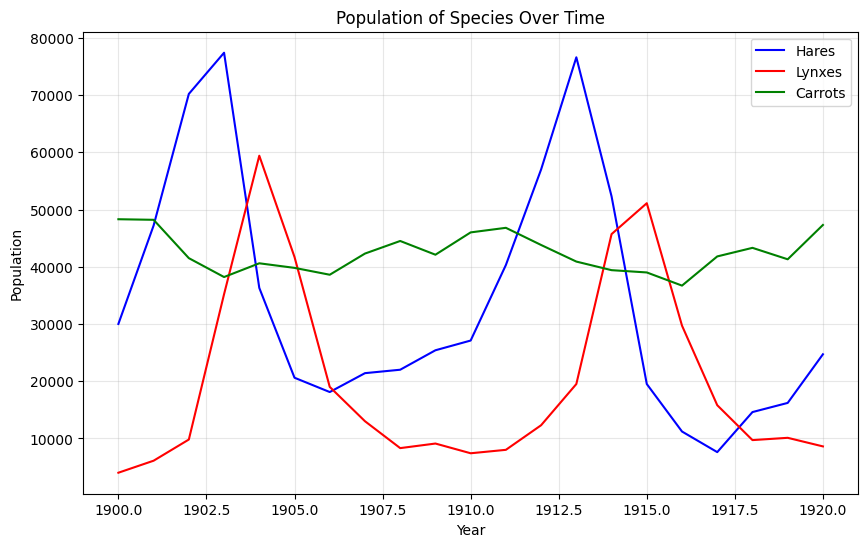

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(years, hares, 'b-', label='Hares')
plt.plot(years, lynxes, 'r-', label='Lynxes')
plt.plot(years, carrots, 'g-', label='Carrots')
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Population of Species Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- Find which year each species had the largest population. Mark these years in the plot of populations.

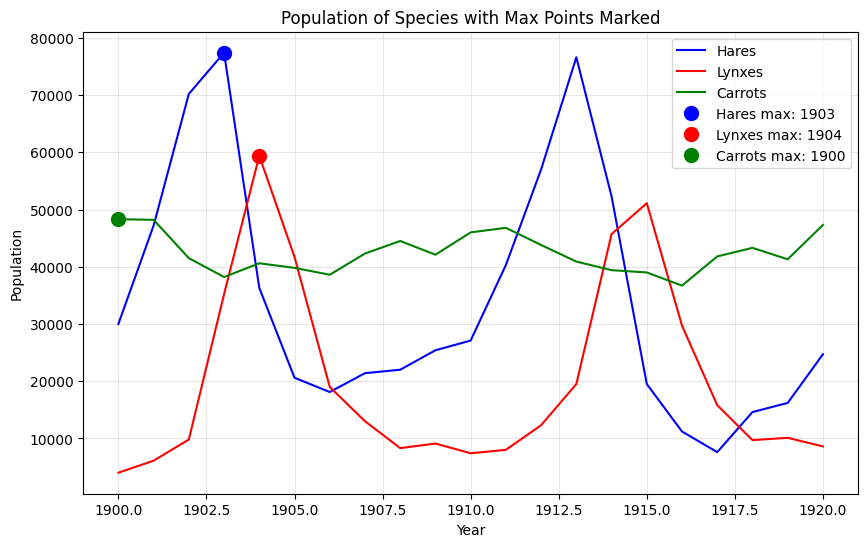

Год максимальной популяции зайцев: 1903
Год максимальной популяции рысей: 1904
Год максимальной популяции моркови: 1900


In [ ]:
max_hare_year = years[np.argmax(hares)]
max_lynx_year = years[np.argmax(lynxes)]
max_carrot_year = years[np.argmax(carrots)]

plt.figure(figsize=(10, 6))
plt.plot(years, hares, 'b-', label='Hares')
plt.plot(years, lynxes, 'r-', label='Lynxes')
plt.plot(years, carrots, 'g-', label='Carrots')
plt.plot(max_hare_year, max(hares), 'bo', markersize=10, label=f'Hares max: {max_hare_year}')
plt.plot(max_lynx_year, max(lynxes), 'ro', markersize=10, label=f'Lynxes max: {max_lynx_year}')
plt.plot(max_carrot_year, max(carrots), 'go', markersize=10, label=f'Carrots max: {max_carrot_year}')
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Population of Species with Max Points Marked')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Год максимальной популяции зайцев: {max_hare_year}")
print(f"Год максимальной популяции рысей: {max_lynx_year}")
print(f"Год максимальной популяции моркови: {max_carrot_year}")

- Assuming total population of hares and lynxes is 100%, plot stacked bar graph showing ratio of each specis for each year in the period.

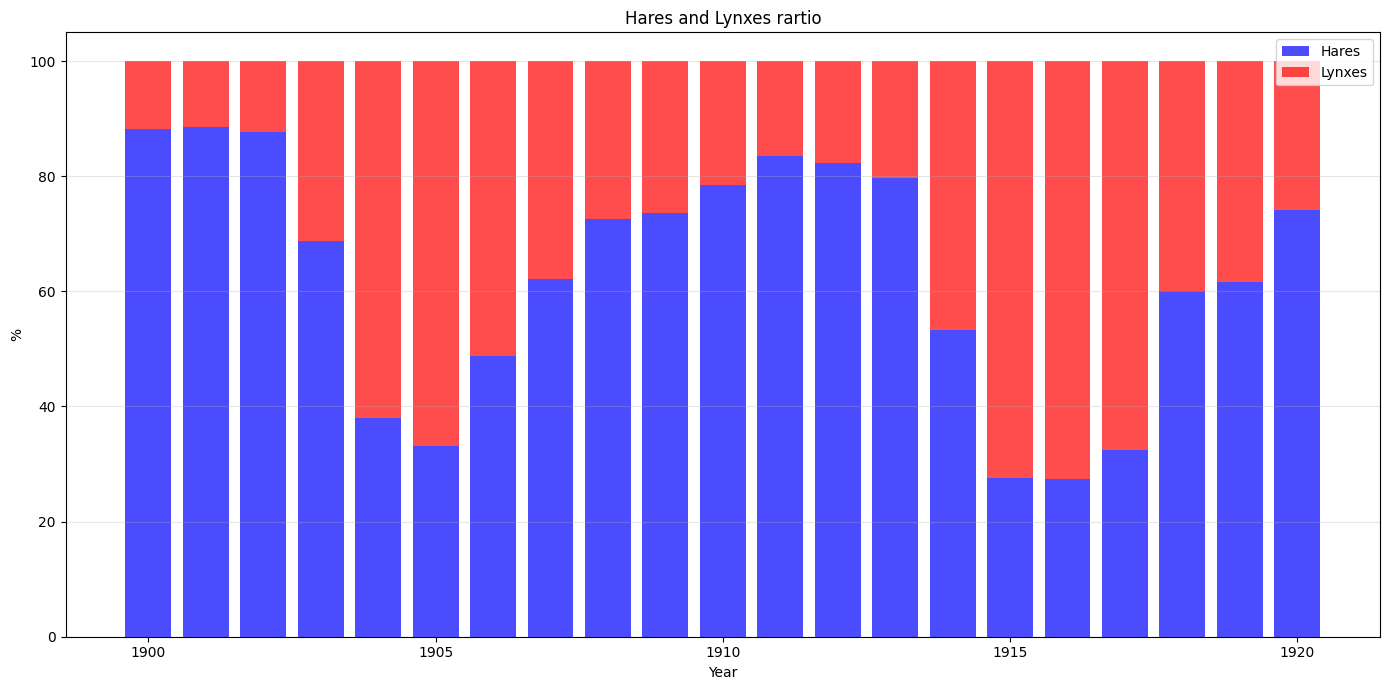

In [ ]:
total_hl = hares + lynxes
hares_pct = (hares / total_hl) * 100
lynxes_pct = (lynxes / total_hl) * 100

plt.figure(figsize=(14, 7))
plt.bar(years, hares_pct, label='Hares', color='blue', alpha=0.7)
plt.bar(years, lynxes_pct, bottom=hares_pct, label='Lynxes', color='red', alpha=0.7)

plt.xlabel('Year')
plt.ylabel('%')
plt.title('Hares and Lynxes rartio')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

- Find the mean and std of the populations of each species. Plot the historgam of population for each species and show mean values with vertical line. Show each histogram in a separate plot. Arrange 3 plots in a row.

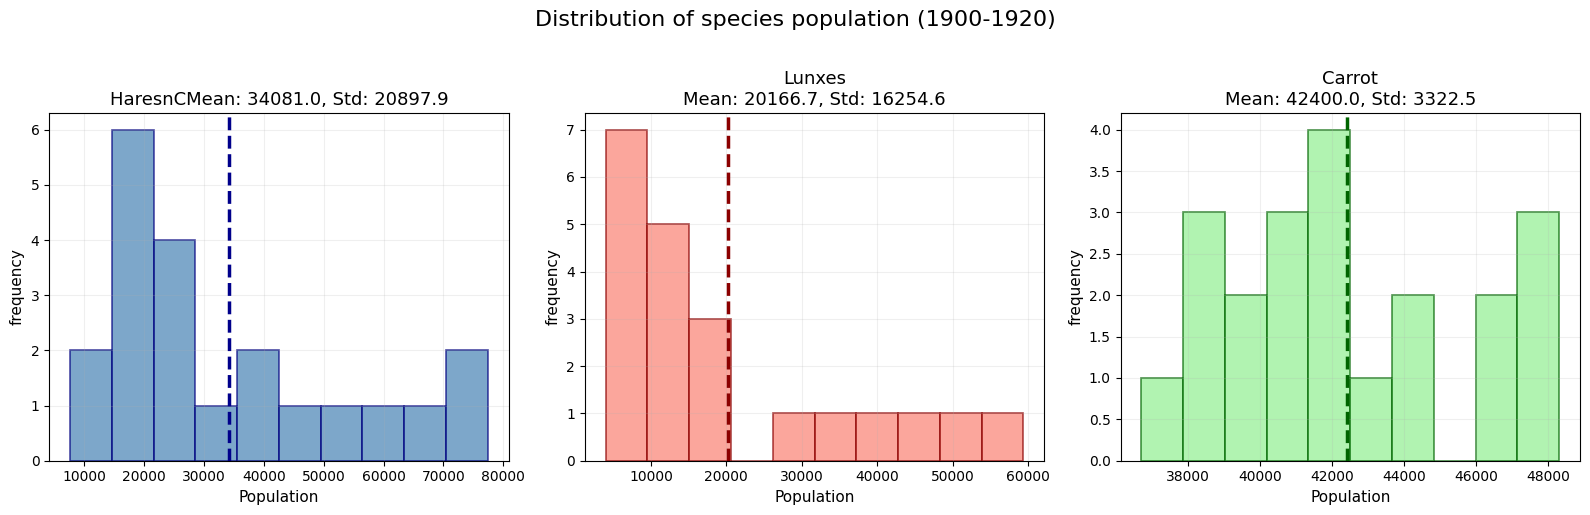

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(hares, bins=10, color='steelblue', alpha=0.7, edgecolor='navy', linewidth=1.2)
axes[0].axvline(np.mean(hares), color='darkblue', linestyle='--', linewidth=2.5)
axes[0].set_title(f'HaresnСMean: {np.mean(hares):.1f}, Std: {np.std(hares):.1f}', fontsize=13)
axes[0].set_xlabel('Population', fontsize=11)
axes[0].set_ylabel('frequency', fontsize=11)
axes[0].grid(True, alpha=0.2)

axes[1].hist(lynxes, bins=10, color='salmon', alpha=0.7, edgecolor='darkred', linewidth=1.2)
axes[1].axvline(np.mean(lynxes), color='darkred', linestyle='--', linewidth=2.5)
axes[1].set_title(f'Lunxes\nMean: {np.mean(lynxes):.1f}, Std: {np.std(lynxes):.1f}', fontsize=13)
axes[1].set_xlabel('Population', fontsize=11)
axes[1].set_ylabel('frequency', fontsize=11)
axes[1].grid(True, alpha=0.2)

axes[2].hist(carrots, bins=10, color='lightgreen', alpha=0.7, edgecolor='darkgreen', linewidth=1.2)
axes[2].axvline(np.mean(carrots), color='darkgreen', linestyle='--', linewidth=2.5)
axes[2].set_title(f'Carrot\nMean: {np.mean(carrots):.1f}, Std: {np.std(carrots):.1f}', fontsize=13)
axes[2].set_xlabel('Population', fontsize=11)
axes[2].set_ylabel('frequency', fontsize=11)
axes[2].grid(True, alpha=0.2)

plt.suptitle('Distribution of species population (1900-1920)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

- Find which species (hares or lynxes) has the largest population for each year. Print the result as [H, H, L, H, ...]. Plot a pie chart showing the ratio of "H" and "L" values.

Результат по годам: ['H', 'H', 'H', 'H', 'L', 'L', 'L', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'L', 'L', 'L', 'H', 'H', 'H']


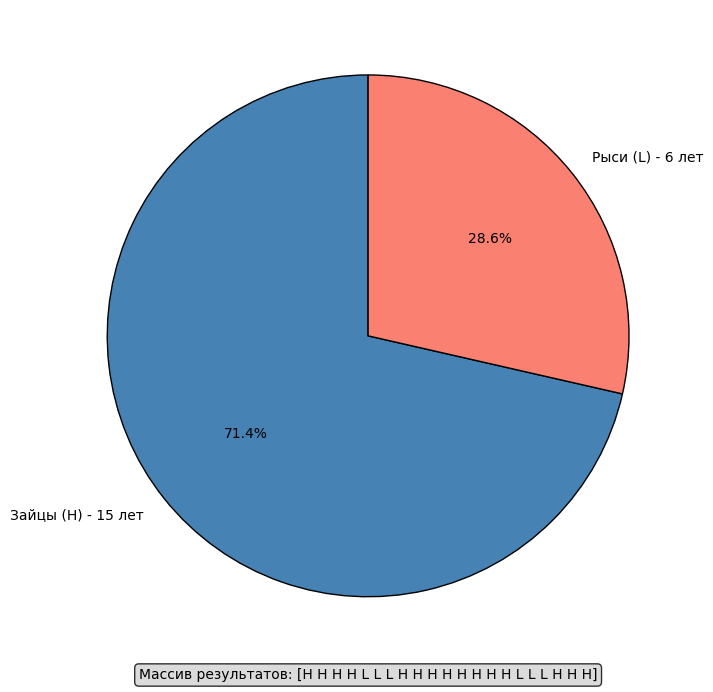

In [ ]:
comparison = np.where(hares > lynxes, 'H', 'L')
print(f"Результат по годам: {comparison.tolist()}")

h_count = np.sum(comparison == 'H')
l_count = np.sum(comparison == 'L')

plt.figure(figsize=(9, 7))
plt.pie([h_count, l_count],
        labels=[f'Зайцы (H) - {h_count} лет', f'Рыси (L) - {l_count} лет'],
        colors=['steelblue', 'salmon'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})

result_str = ' '.join(comparison)
plt.text(0, -1.3, f'Массив результатов: [{result_str}]',
         ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

- Plot the change in the hare population and in the lynx population for each year. Find the correlation coefficient between the both time series.

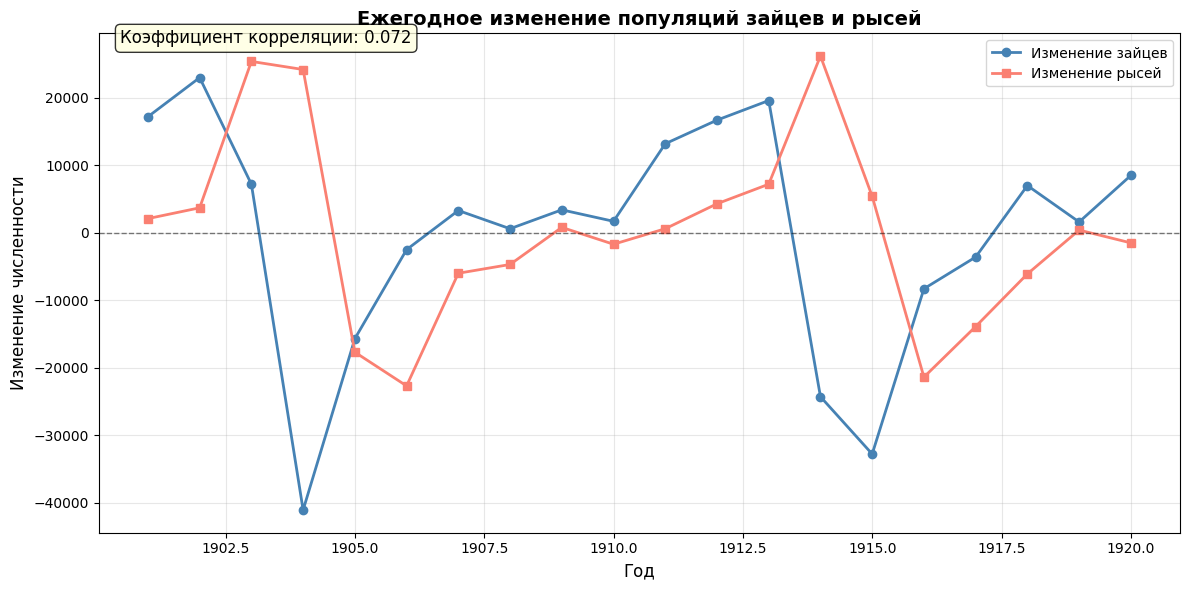

Коэффициент корреляции между изменениями популяций: 0.072


In [ ]:
hare_change = np.diff(hares)
lynx_change = np.diff(lynxes)
change_years = years[1:]

plt.figure(figsize=(12, 6))
plt.plot(change_years, hare_change, 'o-', color='steelblue', linewidth=2, markersize=6, label='Изменение зайцев')
plt.plot(change_years, lynx_change, 's-', color='salmon', linewidth=2, markersize=6, label='Изменение рысей')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1)

plt.xlabel('Год', fontsize=12)
plt.ylabel('Изменение численности', fontsize=12)
plt.title('Ежегодное изменение популяций зайцев и рысей', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

correlation = np.corrcoef(hares, lynxes)[0, 1]
plt.text(0.02, 0.98, f'Коэффициент корреляции: {correlation:.3f}',
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Коэффициент корреляции между изменениями популяций: {correlation:.3f}")

- Using a scatter plot, show the population of hares vs lynxes by year (each point corresponds to a particular year, and the point coordinates correspond to the population of the two species in that year).

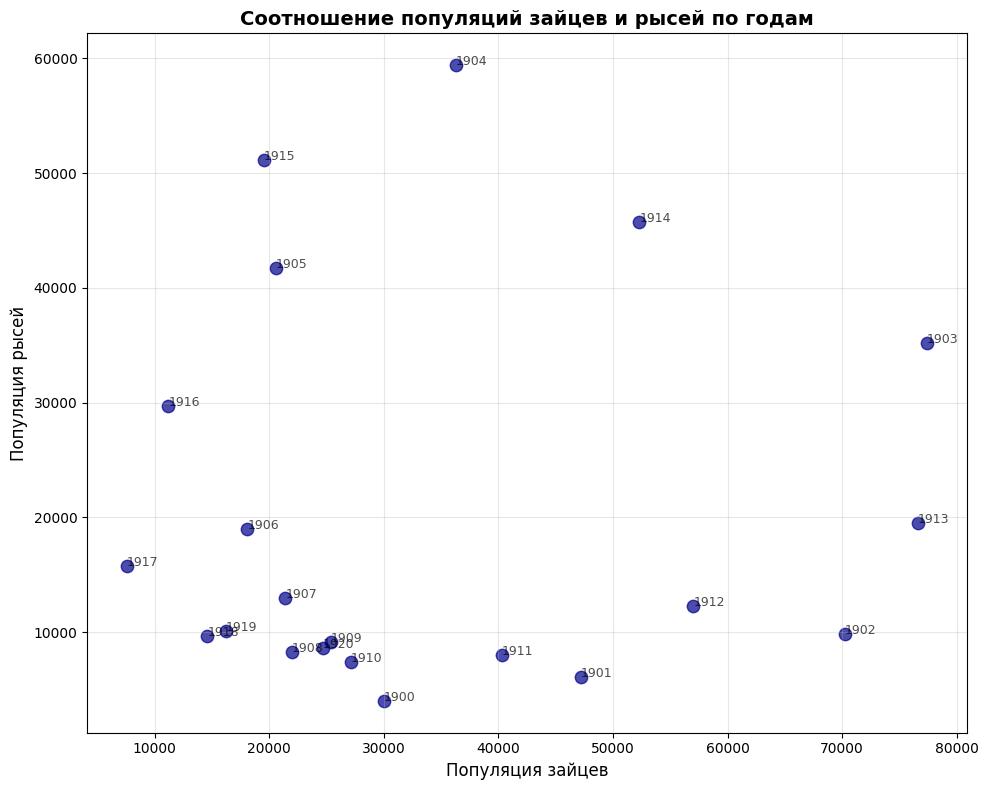

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(hares, lynxes, color='darkblue', s=80, alpha=0.7)

plt.xlabel('Популяция зайцев', fontsize=12)
plt.ylabel('Популяция рысей', fontsize=12)
plt.title('Соотношение популяций зайцев и рысей по годам', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

for i, year in enumerate(years):
    plt.annotate(str(year), (hares[i], lynxes[i]), fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

- Assume the population of hares in 1920 is unknown. Suggest a way to estimate this value. Compare an estimated value
with the true value and print a ratio of the error to the true value.

In [14]:
true_value = hares[-1]

recent_years = hares[-8:-1]
estimated_value = np.mean(recent_years) # просто средним

error_ratio = abs(estimated_value - true_value) / true_value

print(f"Истинная популяция зайцев в 1920 году: {true_value:.0f}")
print(f"Оценка (среднее за 1913-1919): {estimated_value:.0f}")
print(f"Отношение ошибки к истинному значению: {error_ratio:.3f}")

Истинная популяция зайцев в 1920 году: 24700
Оценка (среднее за 1913-1919): 28286
Отношение ошибки к истинному значению: 0.145
